TensorFlow Version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset Information
--------------------------------------------------
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)

Displaying Sample Images Before Normalization...


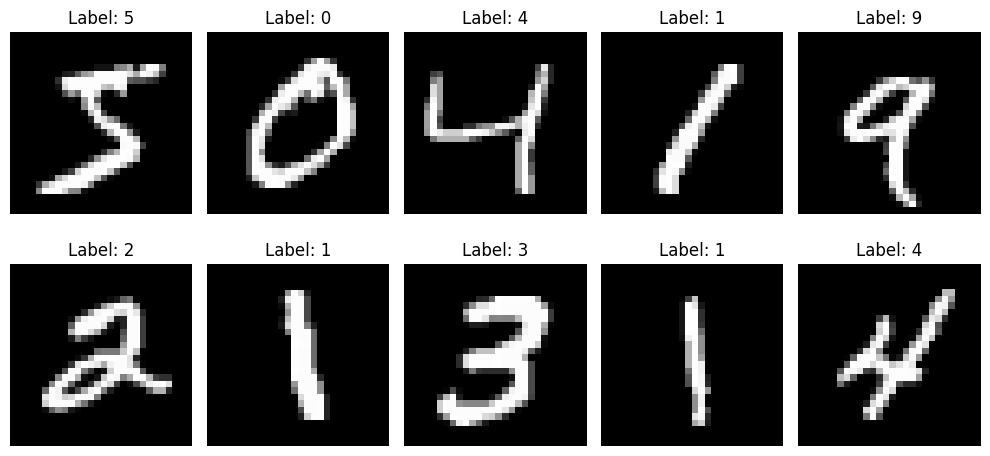


After Normalization
--------------------------------------------------
Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0

Displaying Images After Normalization...


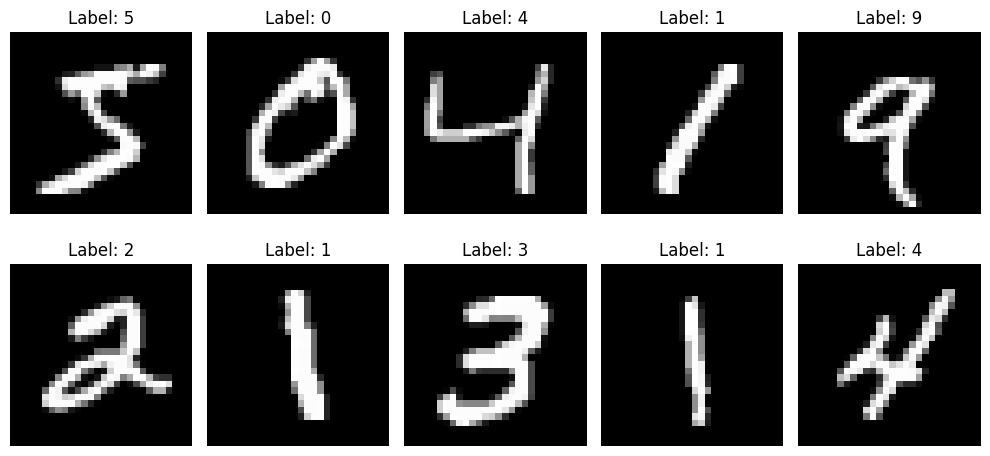


Final Dataset Summary
--------------------------------------------------
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)

Training Pixel Range : 0.0 to 1.0
Testing Pixel Range  : 0.0 to 1.0

Practical Completed Successfully!


In [ ]:
# Practical 1: Data preprocessing, normalization, train-test split, and visualization on MNIST dataset

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print("=" * 50)
print("TensorFlow Version:", tf.__version__)
print("=" * 50)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("\nDataset Information")
print("-" * 50)
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

print("\nDisplaying Sample Images Before Normalization...")

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: {}".format(y_train[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("\nAfter Normalization")
print("-" * 50)
print("Minimum Pixel Value :", x_train.min())
print("Maximum Pixel Value :", x_train.max())

print("\nDisplaying Images After Normalization...")

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: {}".format(y_train[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\nFinal Dataset Summary")
print("-" * 50)
print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

print("\nTraining Pixel Range :", x_train.min(), "to", x_train.max())
print("Testing Pixel Range  :", x_test.min(), "to", x_test.max())

print("\nPractical Completed Successfully!")

Input Dataset:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Target Output:
[0 0 0 1]

Weights = [1 1]
Bias = -1.5

Input	Actual	Predicted
[0 0]	0	0
[0 1]	0	0
[1 0]	0	0
[1 1]	1	1

========== Effect of Weights ==========

Weights = [0.5 0.5]
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 0

Weights = [2 2]
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1

========== Effect of Bias ==========

Bias = -0.5
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1

Bias = -1.5
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

Bias = -2
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


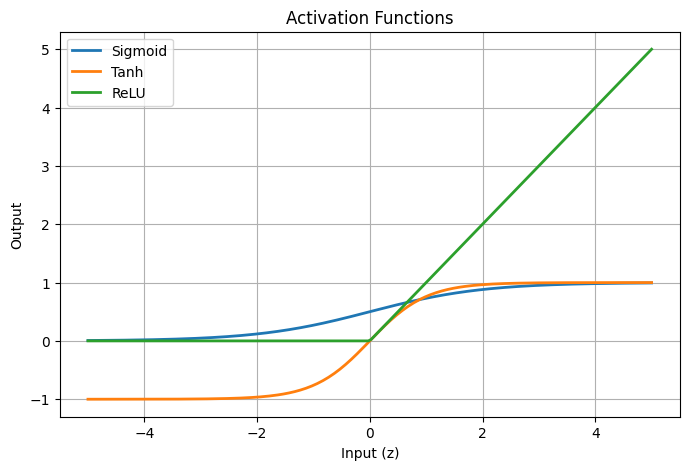

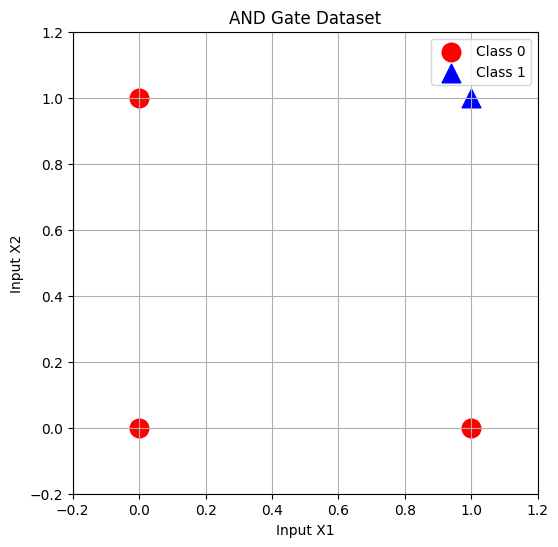

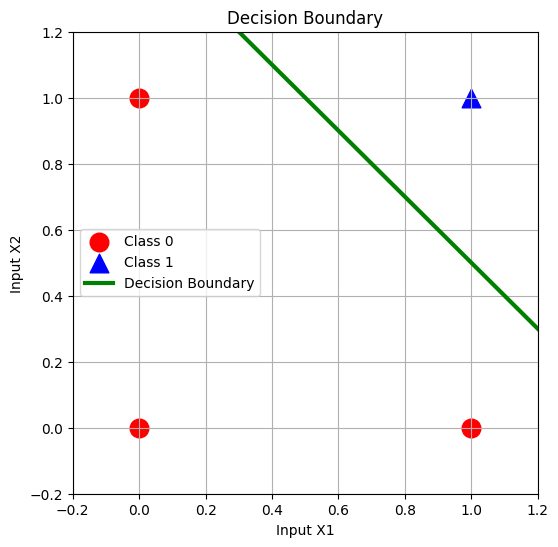

In [ ]:
# Practical 2: Single Layer Perceptron using AND Gate (extra)

import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

Y = np.array([0,0,0,1])

print("Input Dataset:")
print(X)

print("\nTarget Output:")
print(Y)


def step(z):
    return 1 if z >= 0 else 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return max(0, z)

weights = np.array([1,1])
bias = -1.5

print("\nWeights =", weights)
print("Bias =", bias)

print("\nInput\tActual\tPredicted")

for x, y in zip(X, Y):
    z = np.dot(x, weights) + bias
    print(f"{x}\t{y}\t{step(z)}")


print("\n========== Effect of Weights ==========")

for w in [np.array([0.5,0.5]), np.array([2,2])]:

    print("\nWeights =", w)

    for x in X:
        z = np.dot(x, w) + bias
        print(x, "->", step(z))


print("\n========== Effect of Bias ==========")

for b in [-0.5, -1.5, -2]:

    print("\nBias =", b)

    for x in X:
        z = np.dot(x, weights) + b
        print(x, "->", step(z))


z = np.linspace(-5, 5, 200)

plt.figure(figsize=(8,5))

plt.plot(z, [sigmoid(i) for i in z], label="Sigmoid", linewidth=2)
plt.plot(z, [tanh(i) for i in z], label="Tanh", linewidth=2)
plt.plot(z, [relu(i) for i in z], label="ReLU", linewidth=2)

plt.title("Activation Functions")
plt.xlabel("Input (z)")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(6,6))

for i in range(len(X)):
    if Y[i] == 0:
        plt.scatter(X[i][0], X[i][1],
                    color='red',
                    marker='o',
                    s=180,
                    label='Class 0' if i == 0 else "")
    else:
        plt.scatter(X[i][0], X[i][1],
                    color='blue',
                    marker='^',
                    s=180,
                    label='Class 1')

plt.xlim(-0.2,1.2)
plt.ylim(-0.2,1.2)

plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.title("AND Gate Dataset")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(6,6))

for i in range(len(X)):
    if Y[i] == 0:
        plt.scatter(X[i][0], X[i][1],
                    color='red',
                    marker='o',
                    s=180,
                    label='Class 0' if i == 0 else "")
    else:
        plt.scatter(X[i][0], X[i][1],
                    color='blue',
                    marker='^',
                    s=180,
                    label='Class 1')

x_values = np.linspace(-0.2, 1.2, 100)

y_values = -(weights[0]*x_values + bias) / weights[1]

plt.plot(x_values,
         y_values,
         color='green',
         linewidth=3,
         label='Decision Boundary')

plt.xlim(-0.2,1.2)
plt.ylim(-0.2,1.2)

plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.title("Decision Boundary")
plt.grid(True)
plt.legend()
plt.show()

Dataset Shape : (178, 13)
Number of Features : 13
Number of Classes : 3
Class Names : ['class_0' 'class_1' 'class_2']

Accuracy : 97.22%

Classification Report

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



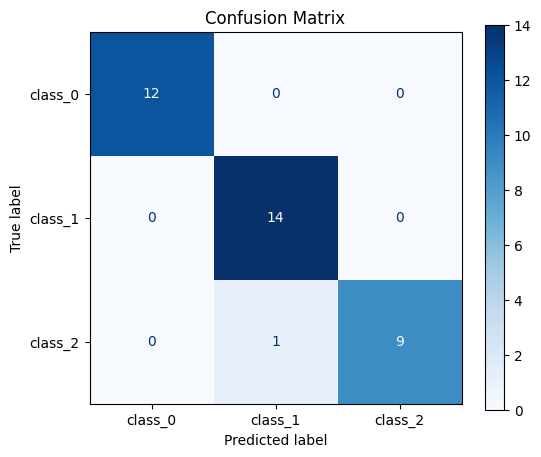

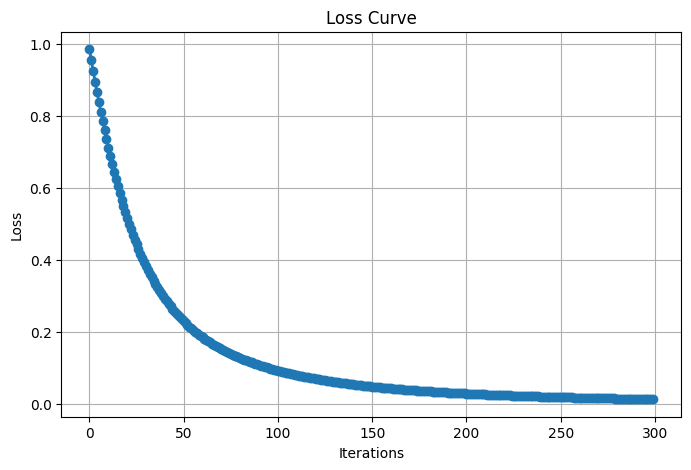

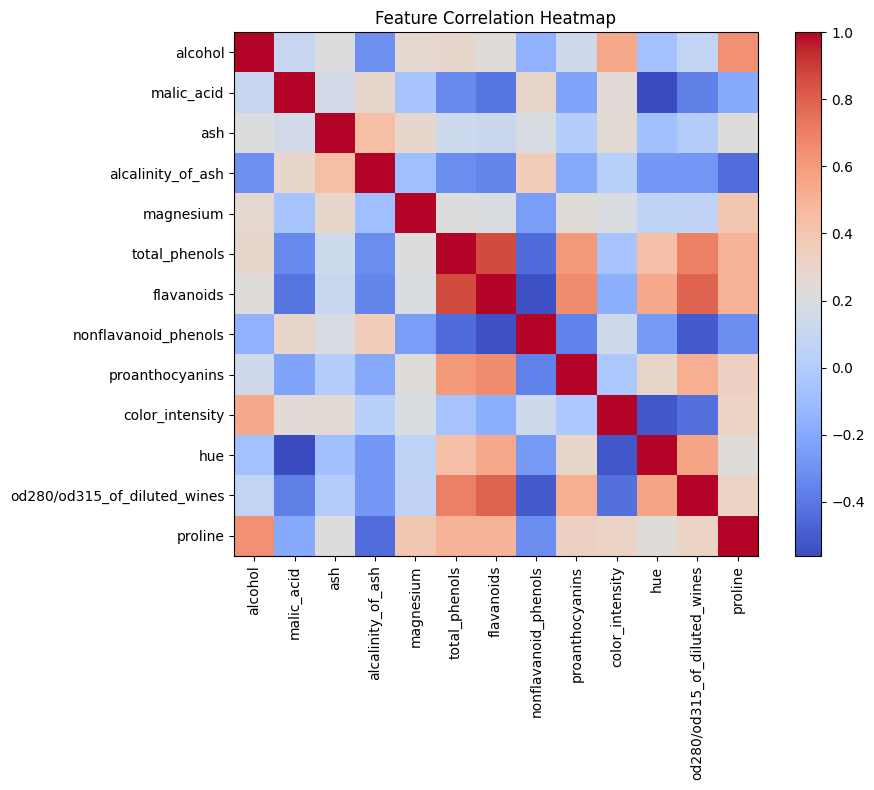

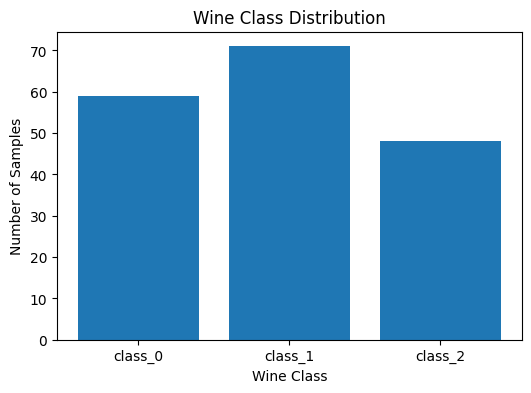

In [ ]:
# Practical 2: Multilayer Perceptron (MLP) on Wine Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


wine = load_wine()

X = wine.data
y = wine.target

print("Dataset Shape :", X.shape)
print("Number of Features :", X.shape[1])
print("Number of Classes :", len(np.unique(y)))
print("Class Names :", wine.target_names)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy : {:.2f}%".format(accuracy*100))

print("\nClassification Report\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

disp.plot(cmap='Blues', ax=ax)

plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_,
         marker='o',
         linewidth=2)

plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

df = pd.DataFrame(X, columns=wine.feature_names)

plt.figure(figsize=(10,8))

plt.imshow(df.corr(),
           cmap='coolwarm',
           interpolation='nearest')

plt.colorbar()

plt.xticks(
    range(len(df.columns)),
    df.columns,
    rotation=90
)

plt.yticks(
    range(len(df.columns)),
    df.columns
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

plt.figure(figsize=(6,4))

classes, counts = np.unique(y, return_counts=True)

plt.bar(
    wine.target_names,
    counts
)

plt.title("Wine Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")

plt.show()

Saving diabetes.csv to diabetes (1).csv
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Training Model -> Learning Rate=0.1, Epochs=20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 73.38%

Training Model -> Learning Rate=0.1, Epochs=50
Test Accuracy: 70.78%

Training Model -> Learning Rate=0.1, Epochs=100
Test Accuracy: 66.88%

Training Model -> Learning Rate=0.01, Epochs=20
Test Accuracy: 75.97%

Training Model -> Learning Rate=0.01, Epochs=50
Test Accuracy: 74.68%

Training Model -> Learning Rate=0.01, Epochs=100
Test Accuracy: 72.08%

Training Model -> Learning Rate=0.001, Epochs=20
Test Accuracy: 71.43%

Training Model -> Learning Rate=0.001, Epochs=50
Test Accuracy: 74.68%

Training Model -> Learning Rate=0.001, Epochs=100
Test Accuracy: 70.13%

Comparison of Learning Rates and Epochs
   Learning Rate  Epochs  Test Accuracy
0          0.100      20       0.733766
1          0.100      50       0.707792
2          0.100     100       0.668831
3          0.010      20       0.759740
4          0.010      50       0.746753
5          0.010     100       0.720779
6          0.001      20       0.714286
7          0.001      50       0.746753
8    

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3279 - loss: 0.8192 - val_accuracy: 0.3821 - val_loss: 0.7484
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3340 - loss: 0.7738 - val_accuracy: 0.4390 - val_loss: 0.7265
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3931 - loss: 0.7401 - val_accuracy: 0.4390 - val_loss: 0.7094
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4868 - loss: 0.7140 - val_accuracy: 0.5041 - val_loss: 0.6944
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5804 - loss: 0.6912 - val_accuracy: 0.5935 - val_loss: 0.6777
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6456 - loss: 0.6688 - val_accuracy: 0.6423 - val_loss: 0.6612
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6782 - loss: 0.6456 - val_accuracy: 0.6748 - val_loss: 0.6444
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6782 - loss: 0.6248 - val_accuracy: 0.6992 - val_loss: 0

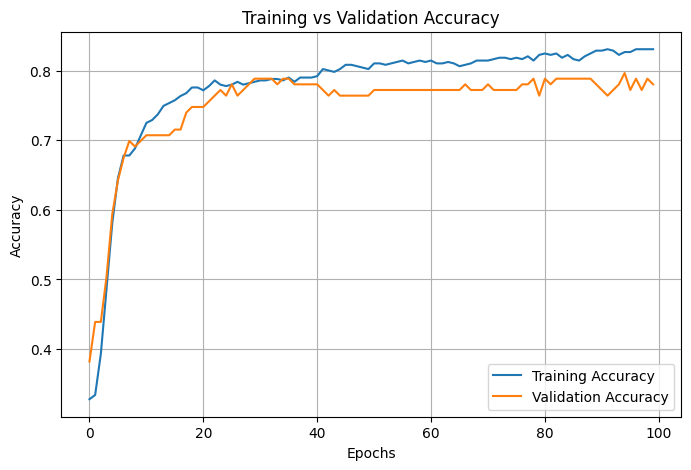

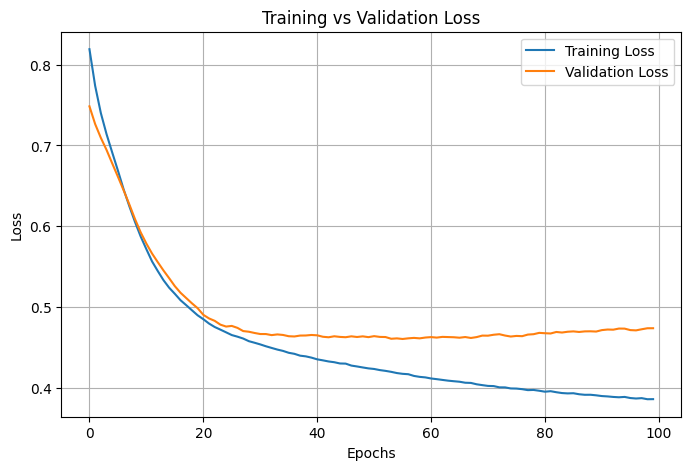

In [ ]:
# Practical 3: Backward and Forward propagation on PIMA Diabetes Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

uploaded = files.upload()

df = pd.read_csv("diabetes.csv")

print(df.head())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def create_model(learning_rate):

    model = Sequential([
        Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

learning_rates = [0.1, 0.01, 0.001]
epochs_list = [20, 50, 100]

results = []

for lr in learning_rates:
    for epochs in epochs_list:

        print(f"\nTraining Model -> Learning Rate={lr}, Epochs={epochs}")

        model = create_model(lr)

        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=epochs,
            batch_size=32,
            verbose=0
        )

        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

        results.append([lr, epochs, accuracy])

        print(f"Test Accuracy: {accuracy*100:.2f}%")

results_df = pd.DataFrame(
    results,
    columns=["Learning Rate", "Epochs", "Test Accuracy"]
)

print("\nComparison of Learning Rates and Epochs")
print(results_df)

best_model = create_model(0.001)

history = best_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

loss, accuracy = best_model.evaluate(X_test, y_test)

print("\nFinal Test Accuracy: {:.2f}%".format(accuracy*100))

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_836/3841737099.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.0053 - val_loss: 8.3765e-04
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 9.4200e-04 - val_loss: 0.0010
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 8.4970e-04 - val_loss: 7.3732e-04
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 5.5954e-04 - val_loss: 0.0014
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 5.8236e-04 - val_loss: 6.7286e-04
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 4.7527e-04 - val_loss: 6.3155e-04
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 5.0400e-04 - val_loss: 5.9132e-04
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5.8840e-04 - val_loss: 7.4843e-04
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 4.6027e-04 - val_loss: 6.2370e-04
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 4.4538e-04 - val_loss: 5.9667e-04
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 4.2029e-04 - val_loss

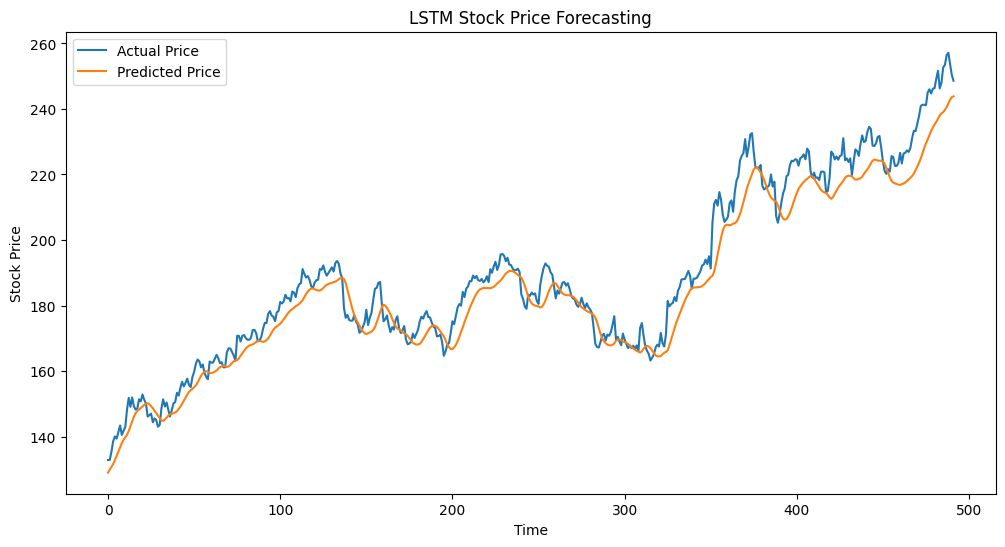

In [1]:
# Practical 4: LSTM for time-series forecasting

!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
data = data[['Close']]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

plt.figure(figsize=(12, 6))
plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("LSTM Stock Price Forecasting")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.5033 - loss: 0.6954 - val_accuracy: 0.5088 - val_loss: 0.6927
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.5950 - loss: 0.6538 - val_accuracy: 0.5074 - val_loss: 0.7048
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.6837 - loss: 0.5229 - val_accuracy: 0.5038 - val_loss: 0.8046
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.7424 - loss: 0.4031 - val_accuracy: 0.5126 - val_loss: 0.9269
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.7621 - loss: 0.3622 - val_accuracy: 0.5050 - val_loss: 1.0001
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 361ms/step - accuracy: 0.5192 - loss: 0.6924 - val_accuracy: 0.5206 - val_loss: 0.6929
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 360ms/step - accuracy: 0.5800 - loss: 0.6760 - val_accuracy: 0.5062 - val_loss: 0.6957
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 

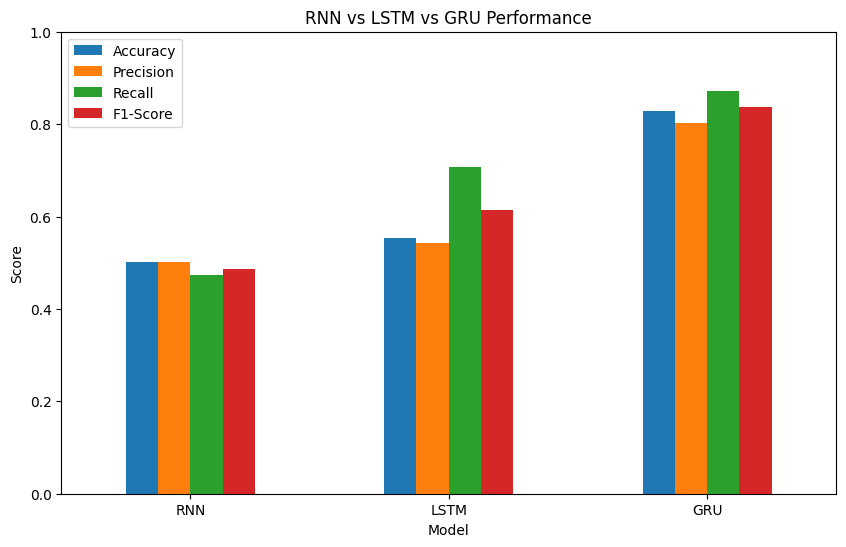

In [2]:
# Practical 5: Comparision between RNN, LSTM and GRU models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

num_words = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

X_train = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post')

def create_rnn():
    model = Sequential([
        Embedding(num_words, 64),
        SimpleRNN(64),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_lstm():
    model = Sequential([
        Embedding(num_words, 64),
        LSTM(64),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def create_gru():
    model = Sequential([
        Embedding(num_words, 64),
        GRU(64),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

rnn_model = create_rnn()
lstm_model = create_lstm()
gru_model = create_gru()

rnn_model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2)
lstm_model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2)
gru_model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2)

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

results = []

for name, model in models.items():
    probabilities = model.predict(X_test)
    predictions = (probabilities >= 0.5).astype(int).flatten()
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    results.append([name, accuracy, precision, recall, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

print(results_df)

results_df.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("RNN vs LSTM vs GRU Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

Upload your kaggle.json file:


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/sivm205/soybean-diseased-leaf-dataset
License(s): unknown
100% 1.93G/1.93G [00:28<00:00, 72.4MB/s]

/content/soybean
/content/soybean/powdery_mildew
/content/soybean/brown_spot
/content/soybean/Southern blight
/content/soybean/Yellow Mosaic
/content/soybean/Mossaic Virus
/content/soybean/Sudden Death Syndrone
/content/soybean/crestamento
/content/soybean/ferrugen
/content/soybean/septoria
/content/soybean/bacterial_blight
Possible dataset directory: /content/soybean
Classes: ['powdery_mildew', 'brown_spot', 'Southern blight', 'Yellow Mosaic', 'Mossaic Virus', 'Sudden Death Syndrone', 'crestamento', 'ferrugen', 'septoria', 'bacterial_blight']
Found 701 files belonging to 10 classes.
Using 561 files for training.
Found 701 files belonging to 10 classes.
Using 140 files for validation.

Disease Classes:
['Mossaic 

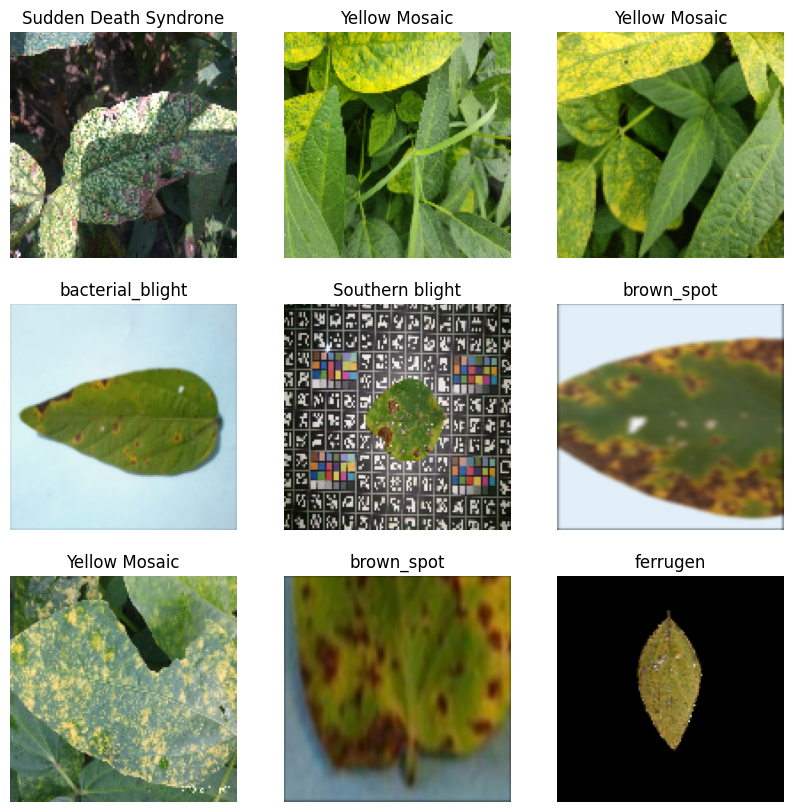

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.6132 - loss: 1.3031 - val_accuracy: 0.7429 - val_loss: 0.8489
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.8271 - loss: 0.5961 - val_accuracy: 0.8357 - val_loss: 0.5375
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.8877 - loss: 0.3485 - val_accuracy: 0.8643 - val_loss: 0.4477
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9216 - loss: 0.2402 - val_accuracy: 0.9214 - val_loss: 0.3181
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.9465 - loss: 0.1949 - val_accuracy: 0.8500 - val_loss: 0.5378
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9501 - loss: 0.2006 - val_accuracy: 0.8214 - val_loss: 0.5746
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.9554 - loss: 0.1747 - val_accuracy: 0.9214 - val_loss: 0.3111
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.9733 - loss: 0.0838 - val_accuracy: 0.9429 - val_loss:

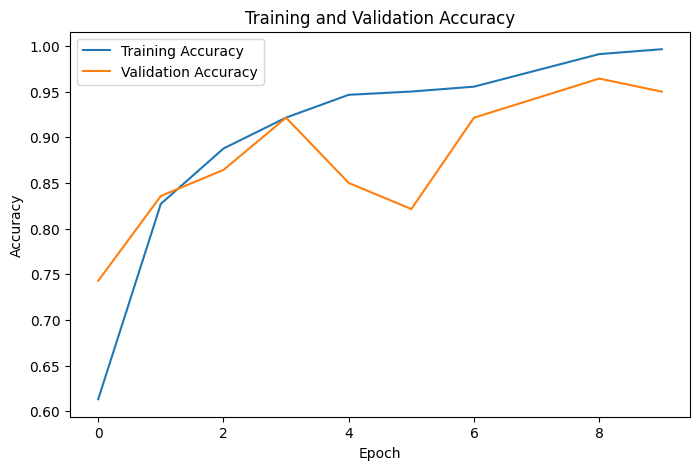

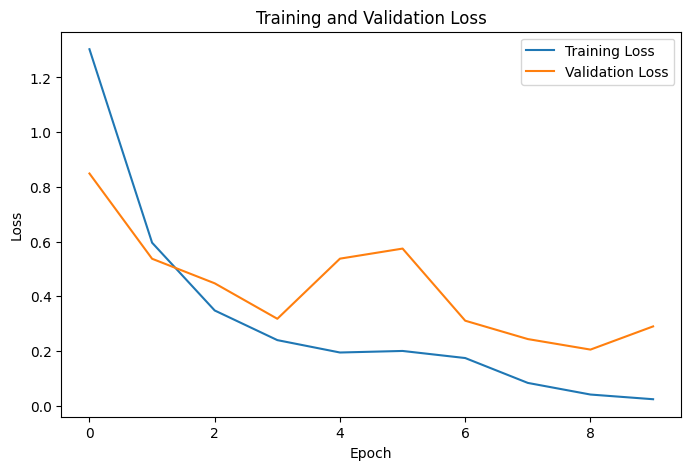


Upload a soybean leaf image for prediction:


AttributeError: 'list' object has no attribute 'upload'

In [ ]:
# Practical 6: CNN for Soyabean disease detection

!pip -q install kaggle

from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


!kaggle datasets download -d sivm205/soybean-diseased-leaf-dataset

import zipfile
import os

zip_file = "/content/soybean-diseased-leaf-dataset.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/soybean")


!find /content/soybean -maxdepth 2 -type d

for root, dirs, files in os.walk("/content/soybean"):
    if len(dirs) > 1:
        print("Possible dataset directory:", root)
        print("Classes:", dirs[:10])

DATASET_PATH = "/content/soybean"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("\nDisease Classes:")
print(class_names)

print("\nNumber of Classes:", len(class_names))

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

num_classes = len(class_names)

model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(128, 128, 3)
    ),

    layers.MaxPooling2D((2, 2)),


    # Convolution Layer 2
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D((2, 2)),


    # Convolution Layer 3
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D((2, 2)),


    # Flatten
    layers.Flatten(),


    # Fully Connected Layer
    layers.Dense(
        128,
        activation='relu'
    ),


    # Output Layer
    layers.Dense(
        num_classes,
        activation='softmax'
    )
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

loss, accuracy = model.evaluate(val_ds)

print("\nValidation Loss:", loss)

print(
    "Validation Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

print("\nUpload a soybean leaf image for prediction:")

uploaded_image = files.upload()

image_path = next(iter(uploaded_image))


# Load Image
img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)


# Convert Image to Array
img_array = tf.keras.utils.img_to_array(img)


# Normalize
img_array = img_array / 255.0


# Add Batch Dimension
img_array = np.expand_dims(
    img_array,
    axis=0
)
prediction = model.predict(img_array)

predicted_class = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction) * 100


print("\nPredicted Disease:", predicted_class)

print(
    "Confidence:",
    round(confidence, 2),
    "%"
)

plt.figure(figsize=(5, 5))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

Device: cuda


100%|██████████| 170M/170M [00:11<00:00, 14.6MB/s]


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 105MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


...

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


AlexNet Epoch 1 Loss: 0.8599930439785028
AlexNet Epoch 2 Loss: 0.6302723339788473
AlexNet Epoch 3 Loss: 0.5580676120177955
AlexNet Test Accuracy: 0.782
AlexNet Test Loss: 0.6038732025772333
VGG16 Epoch 1 Loss: 0.7809735775753192
VGG16 Epoch 2 Loss: 0.5808885862493212
VGG16 Epoch 3 Loss: 0.5405271116905151
VGG16 Test Accuracy: 0.8115
VGG16 Test Loss: 0.5112502658739686
ResNet50 Epoch 1 Loss: 1.2717530529969816
ResNet50 Epoch 2 Loss: 0.7904477313065984
ResNet50 Epoch 3 Loss: 0.678027433764403
ResNet50 Test Accuracy: 0.7755
ResNet50 Test Loss: 0.6836346108466387
EfficientNetB0 Epoch 1 Loss: 1.3424380827861226
EfficientNetB0 Epoch 2 Loss: 0.8518326608998001
EfficientNetB0 Epoch 3 Loss: 0.7610091445552316
EfficientNetB0 Test Accuracy: 0.7745
EfficientNetB0 Test Loss: 0.6836326774209738
            Model  Test Accuracy  Test Loss
0         AlexNet         0.7820   0.603873
1           VGG16         0.8115   0.511250
2        ResNet50         0.7755   0.683635
3  EfficientNetB0         0.7745

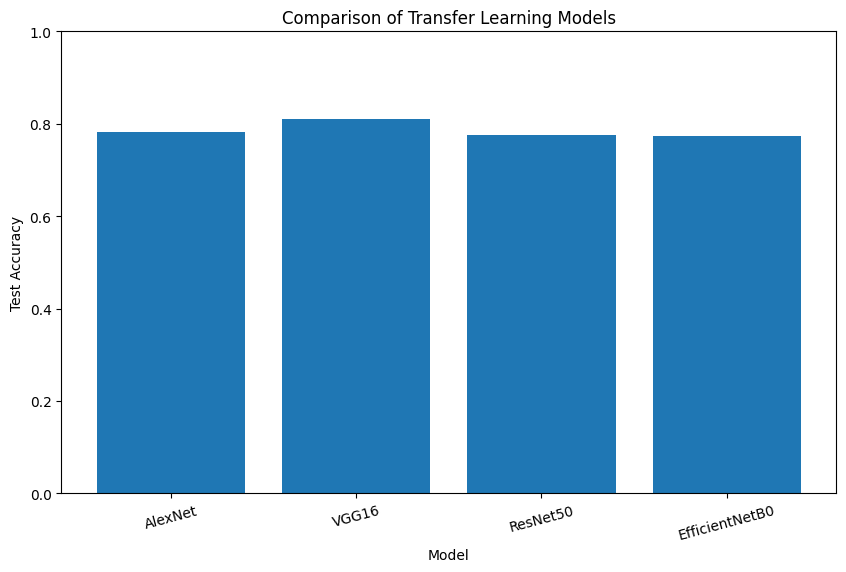

In [1]:
# Practical 7: Transfer learning using pre-trained AlexNet, VGG16, ResNet50, and EfficientNetB0

import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_dataset = Subset(train_dataset, range(10000))
test_dataset = Subset(test_dataset, range(2000))

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

def prepare_model(model, name):
    for param in model.parameters():
        param.requires_grad = False

    if name == "AlexNet":
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)
        trainable = model.classifier[6].parameters()

    elif name == "VGG16":
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)
        trainable = model.classifier[6].parameters()

    elif name == "ResNet50":
        model.fc = nn.Linear(model.fc.in_features, 10)
        trainable = model.fc.parameters()

    else:
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
        trainable = model.classifier[1].parameters()

    model = model.to(device)
    return model, trainable

models_dict = {}

alexnet, alexnet_trainable = prepare_model(alexnet, "AlexNet")
vgg16, vgg16_trainable = prepare_model(vgg16, "VGG16")
resnet50, resnet50_trainable = prepare_model(resnet50, "ResNet50")
efficientnet, efficientnet_trainable = prepare_model(efficientnet, "EfficientNetB0")

models_dict["AlexNet"] = (alexnet, alexnet_trainable)
models_dict["VGG16"] = (vgg16, vgg16_trainable)
models_dict["ResNet50"] = (resnet50, resnet50_trainable)
models_dict["EfficientNetB0"] = (efficientnet, efficientnet_trainable)

criterion = nn.CrossEntropyLoss()

results = []

for name, (model, trainable) in models_dict.items():
    optimizer = optim.Adam(trainable, lr=0.001)

    for epoch in range(3):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(name, "Epoch", epoch + 1, "Loss:", running_loss / len(train_loader))

    model.eval()
    correct = 0
    total = 0
    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    loss_value = test_loss / len(test_loader)

    results.append([name, accuracy, loss_value])

    print(name, "Test Accuracy:", accuracy)
    print(name, "Test Loss:", loss_value)

results_df = pd.DataFrame(
    results,
    columns=["Model", "Test Accuracy", "Test Loss"]
)

print(results_df)

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Comparison of Transfer Learning Models")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()